First steps: importing packages, reading data, and taking an initial look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_data.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


In [4]:
df.describe()


,release_year,duration
count,4812.000000,4812.000000
mean,2012.711554,99.566708
std,9.517978,30.889305
min,1942.000000,1.000000
25%,2011.000000,88.000000
50%,2016.000000,99.000000
75%,2018.000000,116.000000
max,2021.000000,253.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       4812 non-null   str  
 1   type          4812 non-null   str  
 2   title         4812 non-null   str  
 3   director      4812 non-null   str  
 4   cast          4812 non-null   str  
 5   country       4812 non-null   str  
 6   date_added    4812 non-null   str  
 7   release_year  4812 non-null   int64
 8   duration      4812 non-null   int64
 9   description   4812 non-null   str  
 10  genre         4812 non-null   str  
dtypes: int64(2), str(9)
memory usage: 413.7 KB


How many Movies vs TV Shows are on Netflix?


In [6]:
##Answering this question in tabular format
type_count = df['type'].value_counts()
print(type_count)

type
Movie      4677
TV Show     135
Name: count, dtype: int64


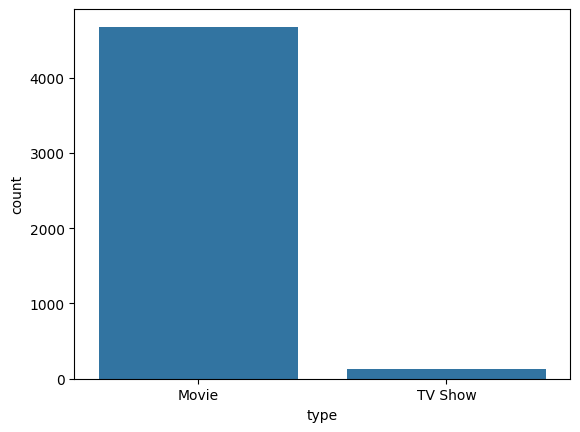

In [7]:
sns.countplot(x=df['type'])
plt.show()

Which 10 countries produce the most Netflix content?

In [8]:
#Answer tabularly
country_count = df['country'].value_counts().sort_values(ascending=False)
print(country_count.head(10))

country
United States     1886
India              864
United Kingdom     311
Canada             155
France             133
Spain              112
Egypt               91
Turkey              81
Japan               81
Mexico              74
Name: count, dtype: int64


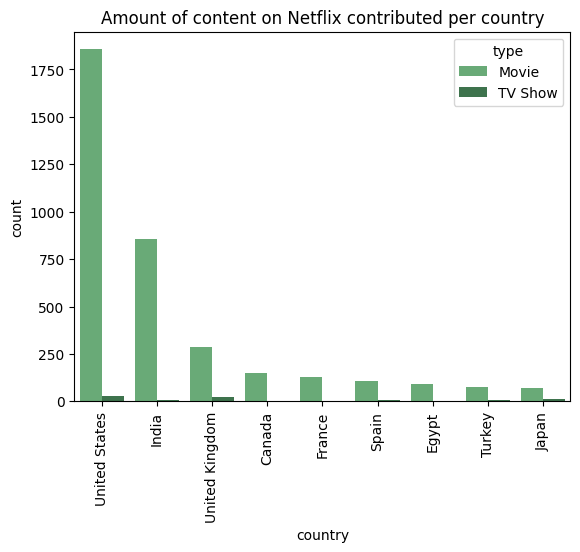

In [9]:
sns.countplot(x=df['country'], palette='Greens_d', hue=df['type'],order=country_count.iloc[0:9].index)
plt.title('Amount of content on Netflix contributed per country')
plt.xticks(rotation=90)
plt.show()

How has the number of titles added to Netflix changed over the years?


In [10]:
#Tabular

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
titles_per_year = pd.DataFrame(df.groupby('year_added')['show_id'].count())
print(titles_per_year)

            show_id
year_added         
2008              1
2009              2
2010              1
2011             13
2012              3
2013              7
2014             14
2015             50
2016            209
2017            754
2018           1114
2019           1337
2020           1229
2021             78


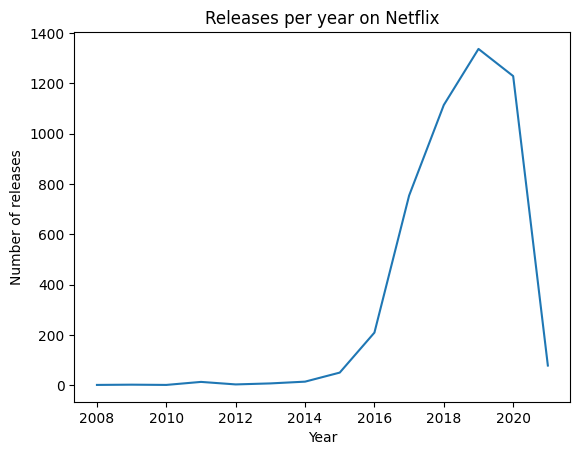

In [11]:
fig, ax = plt.subplots()
ax.plot(titles_per_year.index, titles_per_year.values)
ax.set_title('Releases per year on Netflix')
ax.set_ylabel('Number of releases')
ax.set_xlabel('Year')
plt.show()

/var/folders/tr/zbl6swks2s128fv5r_p1pfbc0000gn/T/ipykernel_57047/2483488724.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['genre'], order=top_10_genres, palette='Greens_d')


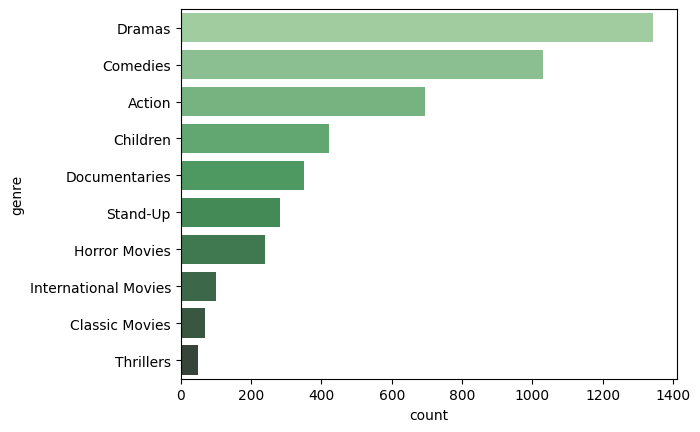

In [12]:
#what are the most common genres?

top_10_genres= df['genre'].value_counts().sort_values(ascending=False).iloc[0:10].index
sns.countplot(df['genre'], order=top_10_genres, palette='Greens_d')
plt.show()

In [13]:
#Has the ratio of Movies vs TV Shows changed over the years?

movies_series = df.groupby('year_added')['type'].value_counts(normalize=True)
print(movies_series)
print('The ratio of movies to tv series on Netflix has not changed much; in this dataset, it fluctuates around 95-98% movies and 5-2% tv series')


year_added  type   
2008        Movie      1.000000
2009        Movie      1.000000
2010        Movie      1.000000
2011        Movie      1.000000
2012        Movie      1.000000
2013        Movie      0.857143
            TV Show    0.142857
2014        Movie      1.000000
2015        Movie      0.940000
            TV Show    0.060000
2016        Movie      0.966507
            TV Show    0.033493
2017        Movie      0.966844
            TV Show    0.033156
2018        Movie      0.985637
            TV Show    0.014363
2019        Movie      0.979058
            TV Show    0.020942
2020        Movie      0.957689
            TV Show    0.042311
2021        Movie      0.961538
            TV Show    0.038462
Name: proportion, dtype: float64
The ratio of movies to tv series on Netflix has not changed much; in this dataset, it fluctuates around 95-98% movies and 5-2% tv series


In [14]:
#Which countries produce the longest movies on average?

duration_per_country = df[df['type'] == 'Movie']
duration_per_country = duration_per_country.groupby('country')['duration'].mean().sort_values(ascending=False)
print(duration_per_country.head(10))

country
Croatia         157.000000
Soviet Union    147.000000
Pakistan        128.117647
India           128.080420
Romania         124.888889
Iran            123.000000
Venezuela       119.000000
Georgia         119.000000
Somalia         118.000000
South Korea     117.078947
Name: duration, dtype: float64


In [ ]:
#Is there a relationship between the country a title is from and its rating (e.g. TV-MA, PG-13)? Focus on the top 5 countries and top 5 ratings.

top_countries = df['country'].value_counts().sort_values(ascending=False).iloc[0:5].index
top_genre = df['genre'].value_counts().sort_values(ascending=False).iloc[0:5].index

top_countries_ratings = df[df['country'].isin(top_countries) & df['genre'].isin(top_genre)]
crosstab = pd.crosstab(top_countries_ratings['country'], top_countries_ratings['genre'], normalize='index')
sns.heatmap(crosstab, annot=True, cmap='Greens_d')
plt.show()

KeyError: "'Greens_d' is not a known colormap name"